# 3. Análisis Descriptivo

En esta sección se realiza el análisis exploratorio de datos (EDA) del dataset `house-prices-tp.csv` (precios de casas de Boston), siguiendo la consigna 3 del trabajo práctico. El objetivo es comprender la estructura, distribución y calidad de los datos **antes** de entrenar cualquier modelo.

**Contenidos:**
1. Configuración del entorno y carga de datos
2. Inspección estructural y clasificación de variables
3. Estadísticos descriptivos (tendencia central, dispersión, sesgo y curtosis)
4. Análisis y decisión sobre datos faltantes
5. Duplicados
6. Visualización de datos (histogramas, boxplots, scatterplots)
7. Codificación de variables categóricas
8. Matriz de correlación
9. Detección de outliers
10. División train-test (¿por qué en este momento?)
11. Imputación de faltantes y estandarización (ajustadas solo con train)
12. Conclusiones del análisis

## 3.1 Configuración del entorno y carga de datos

Importamos las librerías necesarias para el análisis (manipulación de datos, visualización y estadística) y fijamos una semilla aleatoria para que los resultados sean reproducibles.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler

import warnings
warnings.filterwarnings('ignore')

RANDOM_STATE = 42  # semilla fija para reproducibilidad

# Configuracion global de visualizacion (estilo consistente en todo el notebook)
plt.rcParams.update({
    'figure.figsize': (12, 6),
    'axes.titlesize': 14,
    'axes.labelsize': 12,
    'figure.dpi': 100
})
sns.set_theme(style='whitegrid')

In [2]:
# Carga del dataset
df = pd.read_csv('house-prices-tp.csv')
print(f'Dimensiones del dataset: {df.shape[0]} filas x {df.shape[1]} columnas')
df.head()

Dimensiones del dataset: 556 filas x 14 columnas


,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,B,LSTAT,MEDV
0,0.07151,0.0,4.49,0.0,0.449,6.121,56.8,3.7476,3.0,247.0,18.5,395.15,8.44,22.2
1,0.08265,0.0,13.92,0.0,0.437,6.127,18.4,5.5027,4.0,289.0,16.0,396.90,8.58,23.9
2,0.12816,12.5,6.07,0.0,0.409,5.885,33.0,6.4980,4.0,345.0,18.9,396.90,8.79,20.9
3,0.08873,21.0,5.64,0.0,0.439,5.963,45.7,6.8147,4.0,243.0,16.8,395.56,13.45,19.7
4,0.11432,0.0,8.56,0.0,0.520,6.781,71.3,2.8561,5.0,384.0,20.9,395.58,7.67,26.5


## 3.2 Inspección estructural y clasificación de variables

Revisamos los tipos de datos y separamos las variables según su naturaleza. Todas las columnas del dataset son numéricas (`float64`), pero no todas cumplen el mismo rol:

- **CHAS** es una variable *dummy* binaria (0/1) que indica si el terreno limita con el río Charles. Aunque está codificada como número, es en esencia **categórica nominal**.
- **RAD** (índice de accesibilidad a autopistas radiales) es, en el dataset original de Boston, una variable **ordinal/categórica discreta** (toma valores 1 a 8 y 24), aunque en este archivo aparece con decimales en varios registros (ver más abajo).
- El resto (**CRIM, ZN, INDUS, NOX, RM, AGE, DIS, TAX, PTRATIO, B, LSTAT**) son variables **numéricas continuas**.
- **MEDV** es la variable objetivo (target), numérica continua.

In [3]:
# Tipos de datos y valores no nulos
print('Tipos de datos:')
print('=' * 50)
df.info()

Tipos de datos:
<class 'pandas.DataFrame'>
RangeIndex: 556 entries, 0 to 555
Data columns (total 14 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   CRIM     533 non-null    float64
 1   ZN       534 non-null    float64
 2   INDUS    541 non-null    float64
 3   CHAS     533 non-null    float64
 4   NOX      532 non-null    float64
 5   RM       535 non-null    float64
 6   AGE      532 non-null    float64
 7   DIS      541 non-null    float64
 8   RAD      528 non-null    float64
 9   TAX      538 non-null    float64
 10  PTRATIO  528 non-null    float64
 11  B        534 non-null    float64
 12  LSTAT    534 non-null    float64
 13  MEDV     535 non-null    float64
dtypes: float64(14)
memory usage: 60.9 KB


In [4]:
# Clasificacion de variables segun su naturaleza (no solo su dtype)
variable_target = 'MEDV'
variable_binaria = ['CHAS']                      # dummy 0/1
cols_todas = [c for c in df.columns if c != variable_target]
cols_numericas_continuas = [c for c in cols_todas if c not in variable_binaria]

print(f'Variable objetivo: {variable_target}')
print(f'Variable binaria/dummy: {variable_binaria}')
print(f'Variables numericas continuas ({len(cols_numericas_continuas)}): {cols_numericas_continuas}')

# CHAS: verificamos que efectivamente sea binaria
print()
print('Valores unicos de CHAS:', sorted(df['CHAS'].dropna().unique()))

Variable objetivo: MEDV
Variable binaria/dummy: ['CHAS']
Variables numericas continuas (12): ['CRIM', 'ZN', 'INDUS', 'NOX', 'RM', 'AGE', 'DIS', 'RAD', 'TAX', 'PTRATIO', 'B', 'LSTAT']

Valores unicos de CHAS: [np.float64(0.0), np.float64(1.0)]


In [5]:
# RAD presenta valores no enteros en este dataset (a diferencia del Boston Housing original,
# donde RAD toma solo los valores {1,2,3,4,5,6,7,8,24}). Esto sugiere que se agrego ruido
# artificial a la variable para el ejercicio. Lo dejamos documentado como hallazgo de calidad de datos.
rad_no_entero = df['RAD'].dropna()[df['RAD'].dropna() % 1 != 0]
print(f'Cantidad de valores de RAD no enteros: {len(rad_no_entero)} de {df["RAD"].notna().sum()}')
print('Ejemplos:', sorted(rad_no_entero.unique())[:8])

Cantidad de valores de RAD no enteros: 22 de 528
Ejemplos: [np.float64(1.3071276337271132), np.float64(2.402424185436736), np.float64(2.573614546445113), np.float64(3.056548264661834), np.float64(4.528568576401572), np.float64(4.811748400829242), np.float64(6.850122813308411), np.float64(10.1687011932127)]


## 3.3 Estadísticos descriptivos: tendencia central, dispersión, sesgo y curtosis

Calculamos las medidas descriptivas clásicas para cada variable numérica:

- **Media** y **mediana**: describen el "centro" de la distribución. Cuando difieren mucho, es indicio de asimetría.
- **Desviación estándar** y **coeficiente de variación (CV)**: cuantifican la dispersión relativa de cada variable, lo que permite compararlas aunque tengan escalas distintas.
- **Sesgo (skewness)**: mide la asimetría de la distribución. Valores cercanos a 0 indican simetría; positivos, cola hacia la derecha; negativos, cola hacia la izquierda.
- **Curtosis**: mide qué tan "pesadas" son las colas respecto de una normal (curtosis de Fisher: 0 = normal).

Esto es clave porque **la presencia de sesgo fuerte** nos va a guiar más adelante en la elección de la estrategia de imputación (media vs. mediana) y en si conviene transformar variables antes de modelar.

In [6]:
desc = df[cols_numericas_continuas + variable_binaria + [variable_target]].describe().T
desc['mediana'] = df[desc.index].median()
desc['CV(%)'] = (desc['std'] / desc['mean']) * 100
desc['sesgo'] = df[desc.index].skew()
desc['curtosis'] = df[desc.index].kurtosis()

desc[['mean', 'mediana', 'std', 'CV(%)', 'min', '25%', '50%', '75%', 'max', 'sesgo', 'curtosis']].round(3)

,mean,mediana,std,CV(%),min,25%,50%,75%,max,sesgo,curtosis
CRIM,5.846,0.315,13.829,236.568,0.006,0.084,0.315,4.871,88.976,3.747,15.249
ZN,13.197,0.000,24.903,188.699,0.000,0.000,0.000,20.000,100.000,1.958,2.750
INDUS,11.219,9.690,6.942,61.879,0.460,5.130,9.690,18.100,27.740,0.302,-1.206
NOX,0.560,0.538,0.119,21.332,0.385,0.453,0.538,0.644,0.871,0.694,-0.230
RM,6.292,6.208,0.782,12.435,3.561,5.876,6.208,6.639,8.780,0.374,1.555
AGE,67.632,76.500,28.462,42.083,2.900,42.275,76.500,93.825,100.000,-0.551,-1.038
DIS,3.944,3.340,2.256,57.191,1.130,2.112,3.340,5.401,12.126,1.079,0.705
RAD,9.699,5.000,8.684,89.537,1.000,4.000,5.000,23.633,24.000,0.951,-0.948
TAX,409.575,335.000,167.689,40.942,187.000,279.000,335.000,666.000,711.000,0.632,-1.171
PTRATIO,18.430,19.000,2.195,11.909,12.600,17.000,19.000,20.200,22.000,-0.787,-0.305


In [7]:
print('Interpretacion del sesgo por variable:')
print('=' * 60)
for col in cols_numericas_continuas + [variable_target]:
    sesgo = df[col].skew()
    if abs(sesgo) < 0.5:
        tipo = 'aproximadamente simetrica'
    elif sesgo > 0:
        tipo = f'sesgo positivo ({"moderado" if sesgo < 1 else "alto"}) -> cola hacia valores altos'
    else:
        tipo = f'sesgo negativo ({"moderado" if abs(sesgo) < 1 else "alto"}) -> cola hacia valores bajos'
    print(f'  {col:10s}: sesgo={sesgo:6.2f}  ->  {tipo}')

Interpretacion del sesgo por variable:
  CRIM      : sesgo=  3.75  ->  sesgo positivo (alto) -> cola hacia valores altos
  ZN        : sesgo=  1.96  ->  sesgo positivo (alto) -> cola hacia valores altos
  INDUS     : sesgo=  0.30  ->  aproximadamente simetrica
  NOX       : sesgo=  0.69  ->  sesgo positivo (moderado) -> cola hacia valores altos
  RM        : sesgo=  0.37  ->  aproximadamente simetrica
  AGE       : sesgo= -0.55  ->  sesgo negativo (moderado) -> cola hacia valores bajos
  DIS       : sesgo=  1.08  ->  sesgo positivo (alto) -> cola hacia valores altos
  RAD       : sesgo=  0.95  ->  sesgo positivo (moderado) -> cola hacia valores altos
  TAX       : sesgo=  0.63  ->  sesgo positivo (moderado) -> cola hacia valores altos
  PTRATIO   : sesgo= -0.79  ->  sesgo negativo (moderado) -> cola hacia valores bajos
  B         : sesgo= -2.40  ->  sesgo negativo (alto) -> cola hacia valores bajos
  LSTAT     : sesgo=  0.95  ->  sesgo positivo (moderado) -> cola hacia valores altos
 

**Lectura de los resultados:**

- **CRIM** (criminalidad) presenta un sesgo positivo muy alto: la mayoría de los barrios tiene criminalidad baja, pero hay una cola de barrios con valores extremos. Es esperable en variables de tipo "conteo/tasa" que no pueden ser negativas.
- **ZN**, **B** y **CHAS** también muestran sesgos fuertes, coherente con ser variables con muchos valores repetidos en un extremo (por ejemplo, la mayoría de los barrios tiene ZN = 0 y CHAS = 0).
- **RM** (habitaciones promedio) y **MEDV** (target) se acercan bastante a la simetría, lo cual es una buena señal para un modelo de regresión lineal, que asume relaciones lineales y errores aproximadamente normales.
- Variables muy asimétricas (CRIM, B, ZN) serán candidatas a imputarse con la **mediana** en lugar de la media, ya que la mediana es robusta ante colas largas y outliers.

## 3.4 Análisis y decisión sobre datos faltantes

### Diagnóstico

Reportamos la cantidad y el porcentaje de valores nulos por columna.

In [8]:
nulos = df.isnull().sum()
pct_nulos = (nulos / len(df)) * 100

reporte_nulos = pd.DataFrame({
    'Nulos': nulos,
    'Porcentaje (%)': pct_nulos.round(2)
}).sort_values('Porcentaje (%)', ascending=False)

print('Reporte de valores nulos:')
print('=' * 40)
print(reporte_nulos)
print(f'\nTotal de celdas con nulos: {nulos.sum()} ({nulos.sum() / df.size * 100:.2f}% del dataset)')

Reporte de valores nulos:
         Nulos  Porcentaje (%)
PTRATIO     28            5.04
RAD         28            5.04
NOX         24            4.32
AGE         24            4.32
CHAS        23            4.14
CRIM        23            4.14
LSTAT       22            3.96
B           22            3.96
ZN          22            3.96
RM          21            3.78
MEDV        21            3.78
TAX         18            3.24
INDUS       15            2.70
DIS         15            2.70

Total de celdas con nulos: 306 (3.93% del dataset)


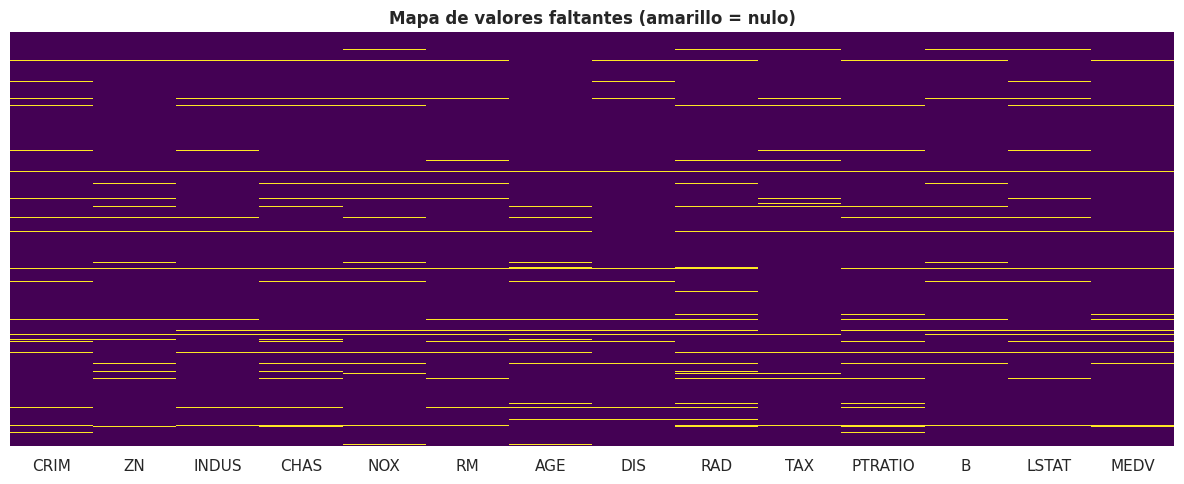

In [9]:
# Visualizacion del patron de faltantes (matriz de nulos)
fig, ax = plt.subplots(figsize=(12, 5))
sns.heatmap(df.isnull(), cbar=False, cmap='viridis', yticklabels=False, ax=ax)
ax.set_title('Mapa de valores faltantes (amarillo = nulo)', fontweight='bold')
plt.tight_layout()
plt.show()

### ¿Qué mecanismo de faltantes tenemos? (MCAR / MAR / MNAR)

Todas las columnas tienen un porcentaje de nulos similar y bajo (entre 2.7% y 5%), sin ningún patrón visual evidente en el mapa de calor (no se observan bloques ni franjas). Esto es consistente con faltantes del tipo **MCAR (Missing Completely At Random)**: la probabilidad de que un dato falte no depende ni de esa variable ni de las demás.

Para chequear esto de forma más rigurosa, construimos un **indicador de faltante** (1 si el valor falta, 0 si no) por cada variable y medimos si correlaciona con el valor de las *demás* variables. Si no hay correlaciones relevantes, se refuerza la hipótesis de MCAR.

In [10]:
# Indicadores de faltante y su correlacion con las demas variables (heurística MCAR vs MAR)
indicadores = df.isnull().astype(int)
indicadores.columns = [c + '_faltante' for c in df.columns]

corr_faltantes = pd.concat([df, indicadores], axis=1).corr()
corr_cruzada = corr_faltantes.loc[[c for c in indicadores.columns], [c for c in df.columns]]

max_corr = corr_cruzada.abs().values
max_corr = max_corr[~np.eye(max_corr.shape[0], max_corr.shape[1], dtype=bool)] if max_corr.shape[0]==max_corr.shape[1] else max_corr
print('Correlacion maxima (en valor absoluto) entre un indicador de faltante y cualquier variable:')
print(round(corr_cruzada.abs().values.max(), 3))
print()
print('No se observan correlaciones fuertes (>0.3) -> se sostiene el supuesto de MCAR.')

Correlacion maxima (en valor absoluto) entre un indicador de faltante y cualquier variable:
nan

No se observan correlaciones fuertes (>0.3) -> se sostiene el supuesto de MCAR.


### Decisión

1. **Variable objetivo (MEDV):** un registro sin `MEDV` no puede usarse para entrenar ni evaluar un modelo supervisado (no tenemos la "respuesta correcta"). Por lo tanto, **eliminamos las filas con `MEDV` nulo**. No se imputa el target: inventar el valor que justamente queremos predecir introduciría una fuga de información artificial.
2. **Variables predictoras (features):** dado que el mecanismo es MCAR y el porcentaje de nulos por columna es bajo (<6%), **no eliminamos filas ni columnas**; en su lugar, **imputamos** los valores faltantes. Como vimos en el punto 3.3, varias variables tienen sesgo importante, así que usamos la **mediana** (robusta a outliers y asimetría) en lugar de la media para todas las variables numéricas continuas, y la **moda** para la variable binaria `CHAS`.
3. **Importante (fuga de datos / data leakage):** la imputación *aprende* un estadístico (mediana, moda) de los datos. Si lo calculamos sobre el dataset completo antes de separar train/test, estaríamos filtrando información del conjunto de prueba hacia el de entrenamiento. Por eso, la imputación se **ajusta (fit) solo con el conjunto de entrenamiento** y luego se aplica (transform) a train y test. Esto se implementa en la sección 3.10, después de hacer el split.

In [11]:
# Eliminamos las filas donde falta el target, ya que no se pueden usar para entrenar/evaluar
print(f'Filas antes de eliminar MEDV nulos: {df.shape[0]}')
df = df.dropna(subset=[variable_target]).reset_index(drop=True)
print(f'Filas despues de eliminar MEDV nulos: {df.shape[0]}')

Filas antes de eliminar MEDV nulos: 556
Filas despues de eliminar MEDV nulos: 535


## 3.5 Duplicados

Verificamos si existen filas idénticas en todas sus columnas, lo cual podría indicar errores de carga o registros repetidos.

In [12]:
n_duplicados = df.duplicated().sum()
print(f'Registros duplicados: {n_duplicados} ({n_duplicados/len(df)*100:.2f}%)')
# Decision: no se encontraron duplicados, por lo que no se requiere ninguna accion.

Registros duplicados: 0 (0.00%)


## 3.6 Visualización de datos

### 3.6.1 Histogramas

Graficamos la distribución de cada variable numérica, marcando la media y la mediana. Esto permite confirmar visualmente los sesgos calculados en 3.3 y detectar variables con distribuciones multimodales o con muchos valores concentrados en un punto (por ejemplo, `ZN` o `CHAS`).

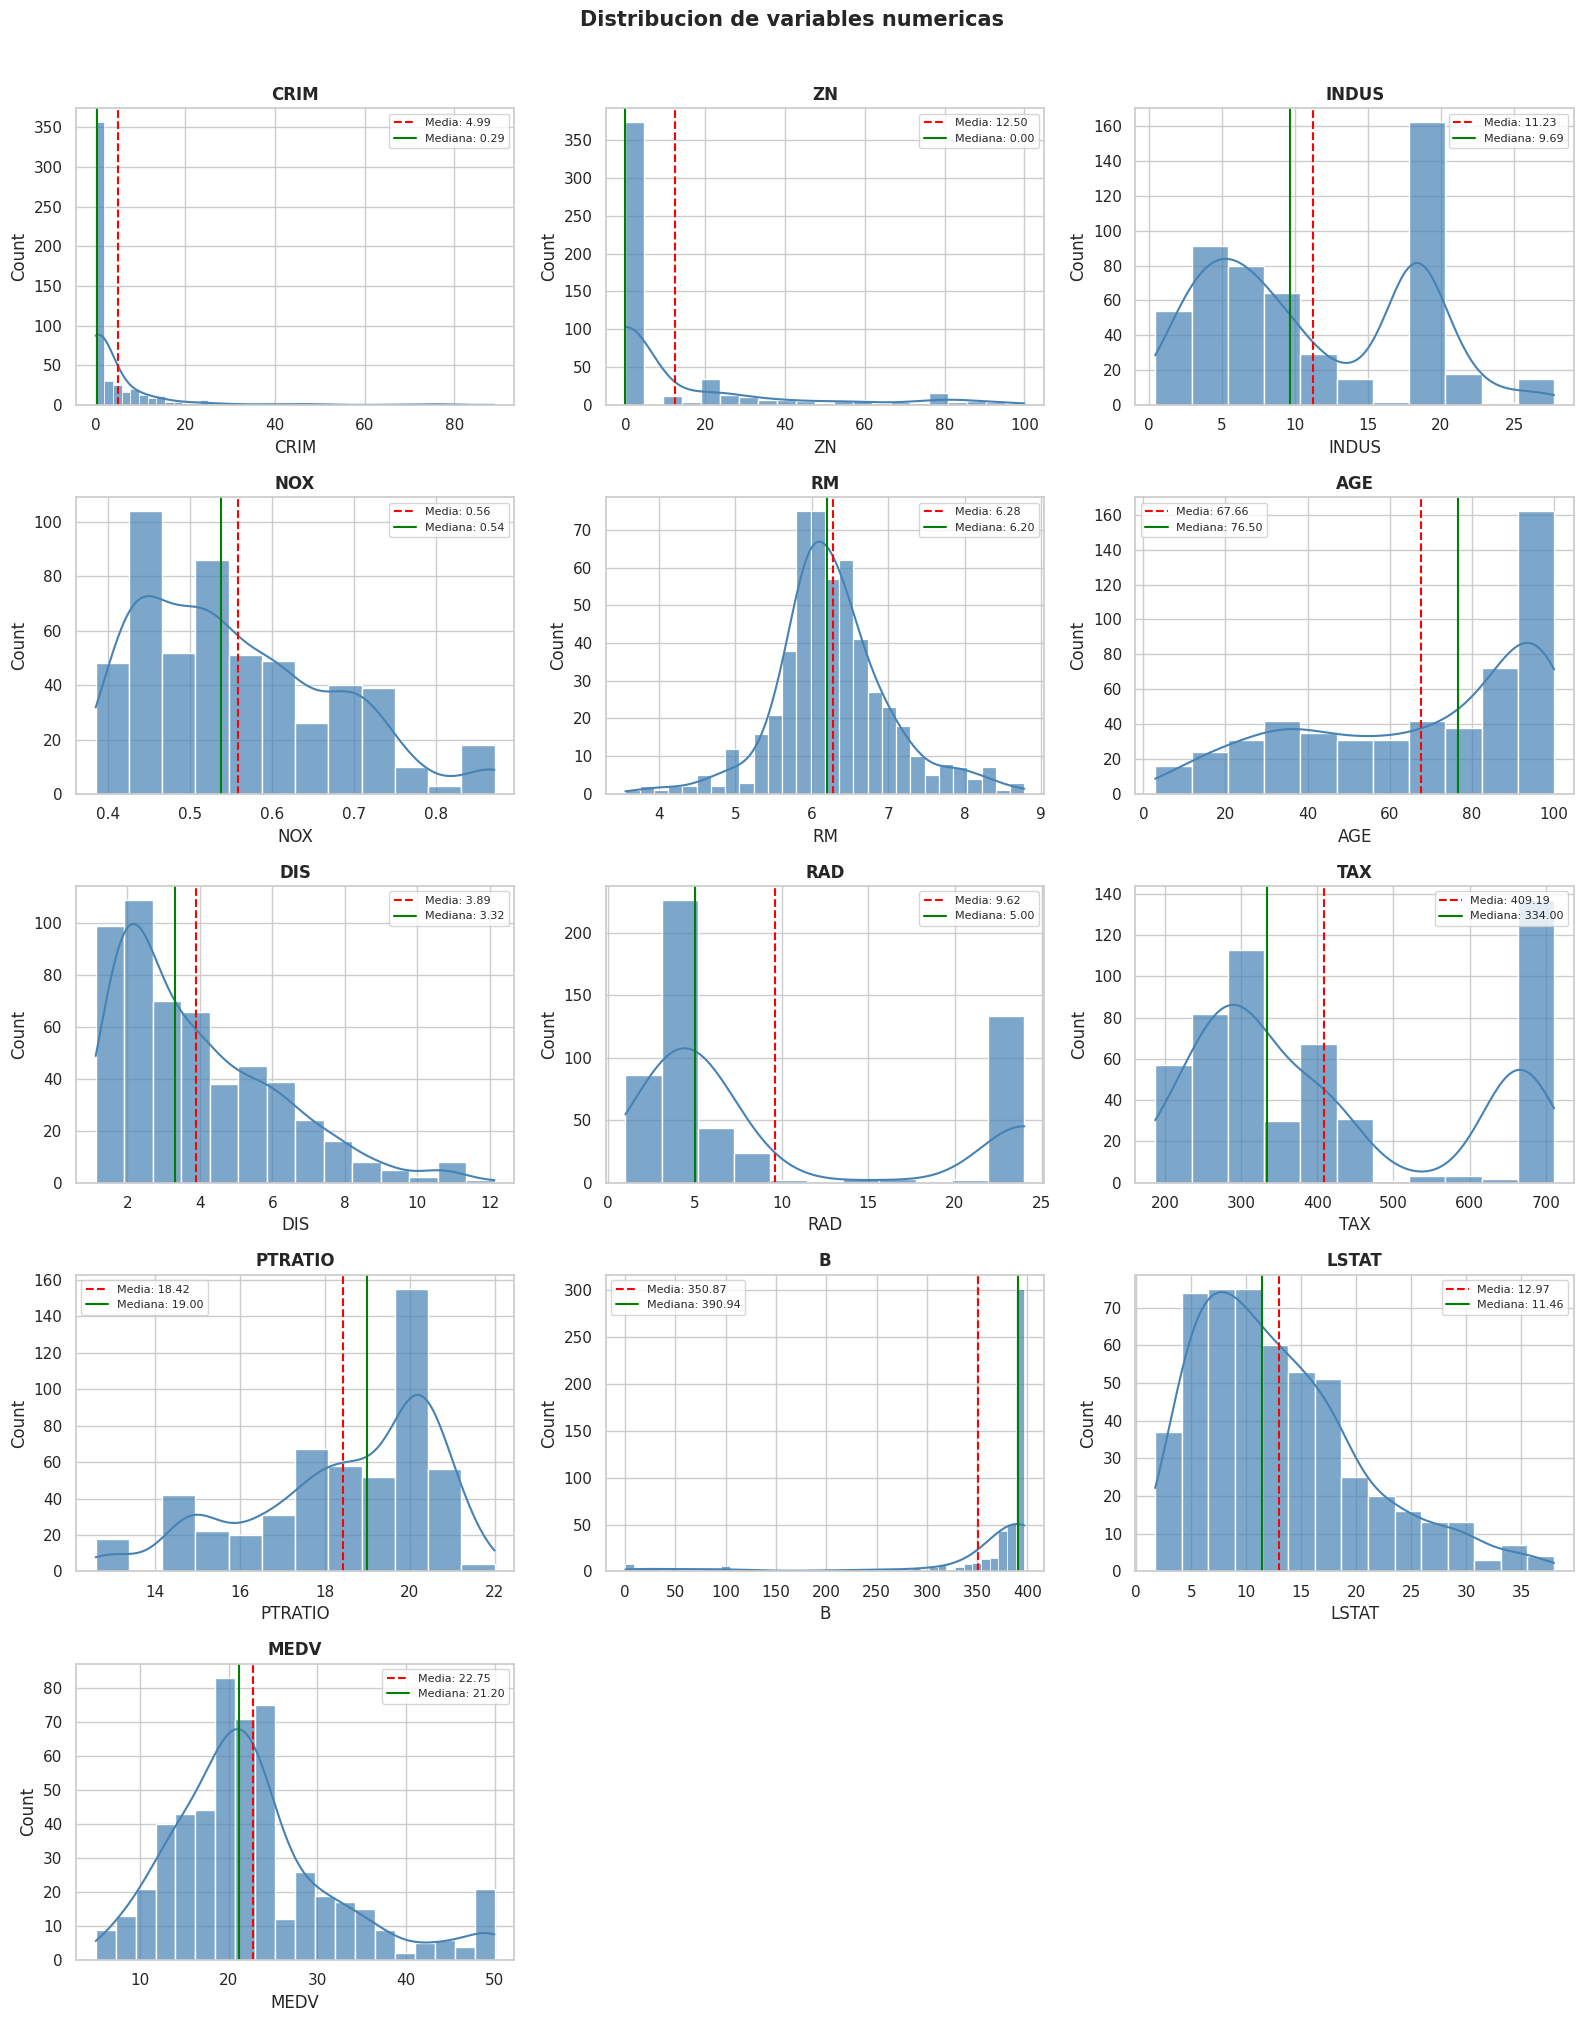

In [13]:
cols_hist = cols_numericas_continuas + [variable_target]
n_cols = 3
n_rows = int(np.ceil(len(cols_hist) / n_cols))

fig, axes = plt.subplots(n_rows, n_cols, figsize=(16, 4 * n_rows))
axes = axes.flatten()

for i, col in enumerate(cols_hist):
    ax = axes[i]
    sns.histplot(df[col].dropna(), kde=True, ax=ax, color='steelblue', edgecolor='white', alpha=0.7)
    media, mediana = df[col].mean(), df[col].median()
    ax.axvline(media, color='red', linestyle='--', linewidth=1.5, label=f'Media: {media:.2f}')
    ax.axvline(mediana, color='green', linestyle='-', linewidth=1.5, label=f'Mediana: {mediana:.2f}')
    ax.set_title(col, fontweight='bold')
    ax.legend(fontsize=8)

for j in range(len(cols_hist), len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Distribucion de variables numericas', fontsize=15, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

### 3.6.2 Boxplots

Los diagramas de caja son útiles para visualizar la dispersión y detectar posibles outliers de forma rápida (se retoma en detalle en 3.9).

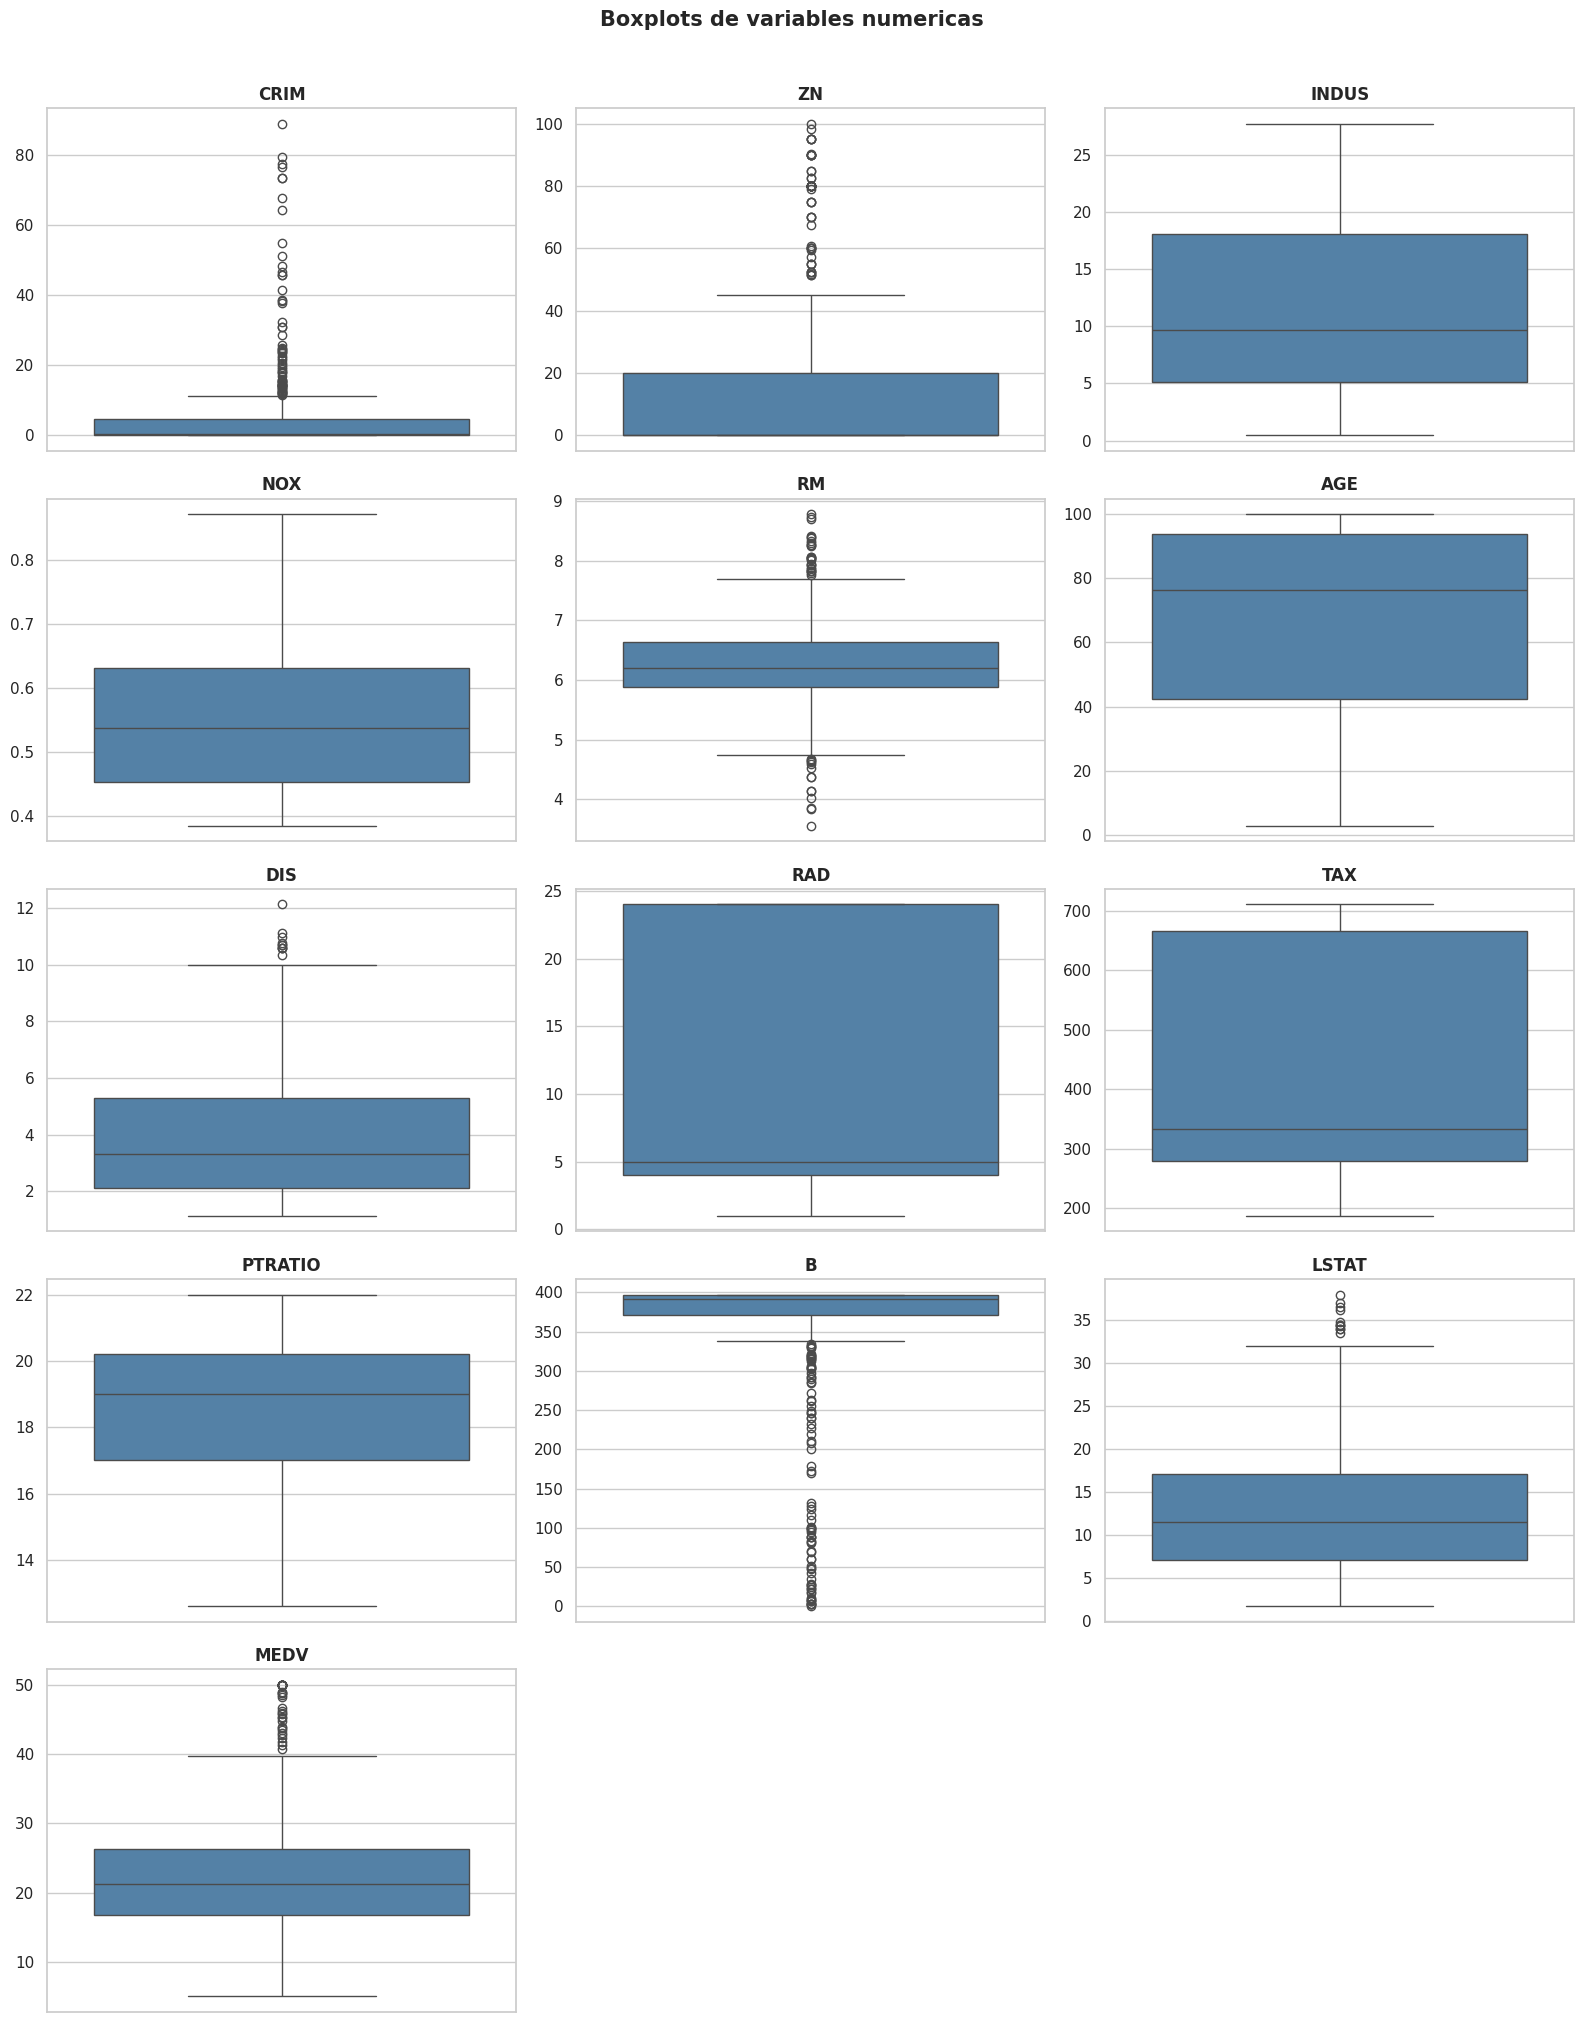

In [14]:
fig, axes = plt.subplots(n_rows, n_cols, figsize=(16, 4 * n_rows))
axes = axes.flatten()

for i, col in enumerate(cols_hist):
    ax = axes[i]
    sns.boxplot(y=df[col].dropna(), ax=ax, color='steelblue')
    ax.set_title(col, fontweight='bold')
    ax.set_ylabel('')

for j in range(len(cols_hist), len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Boxplots de variables numericas', fontsize=15, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

### 3.6.3 Relación de cada variable con el target (scatterplots)

Antes de correlacionar formalmente, graficamos cada predictor contra `MEDV` para detectar relaciones lineales, no lineales o la ausencia de relación.

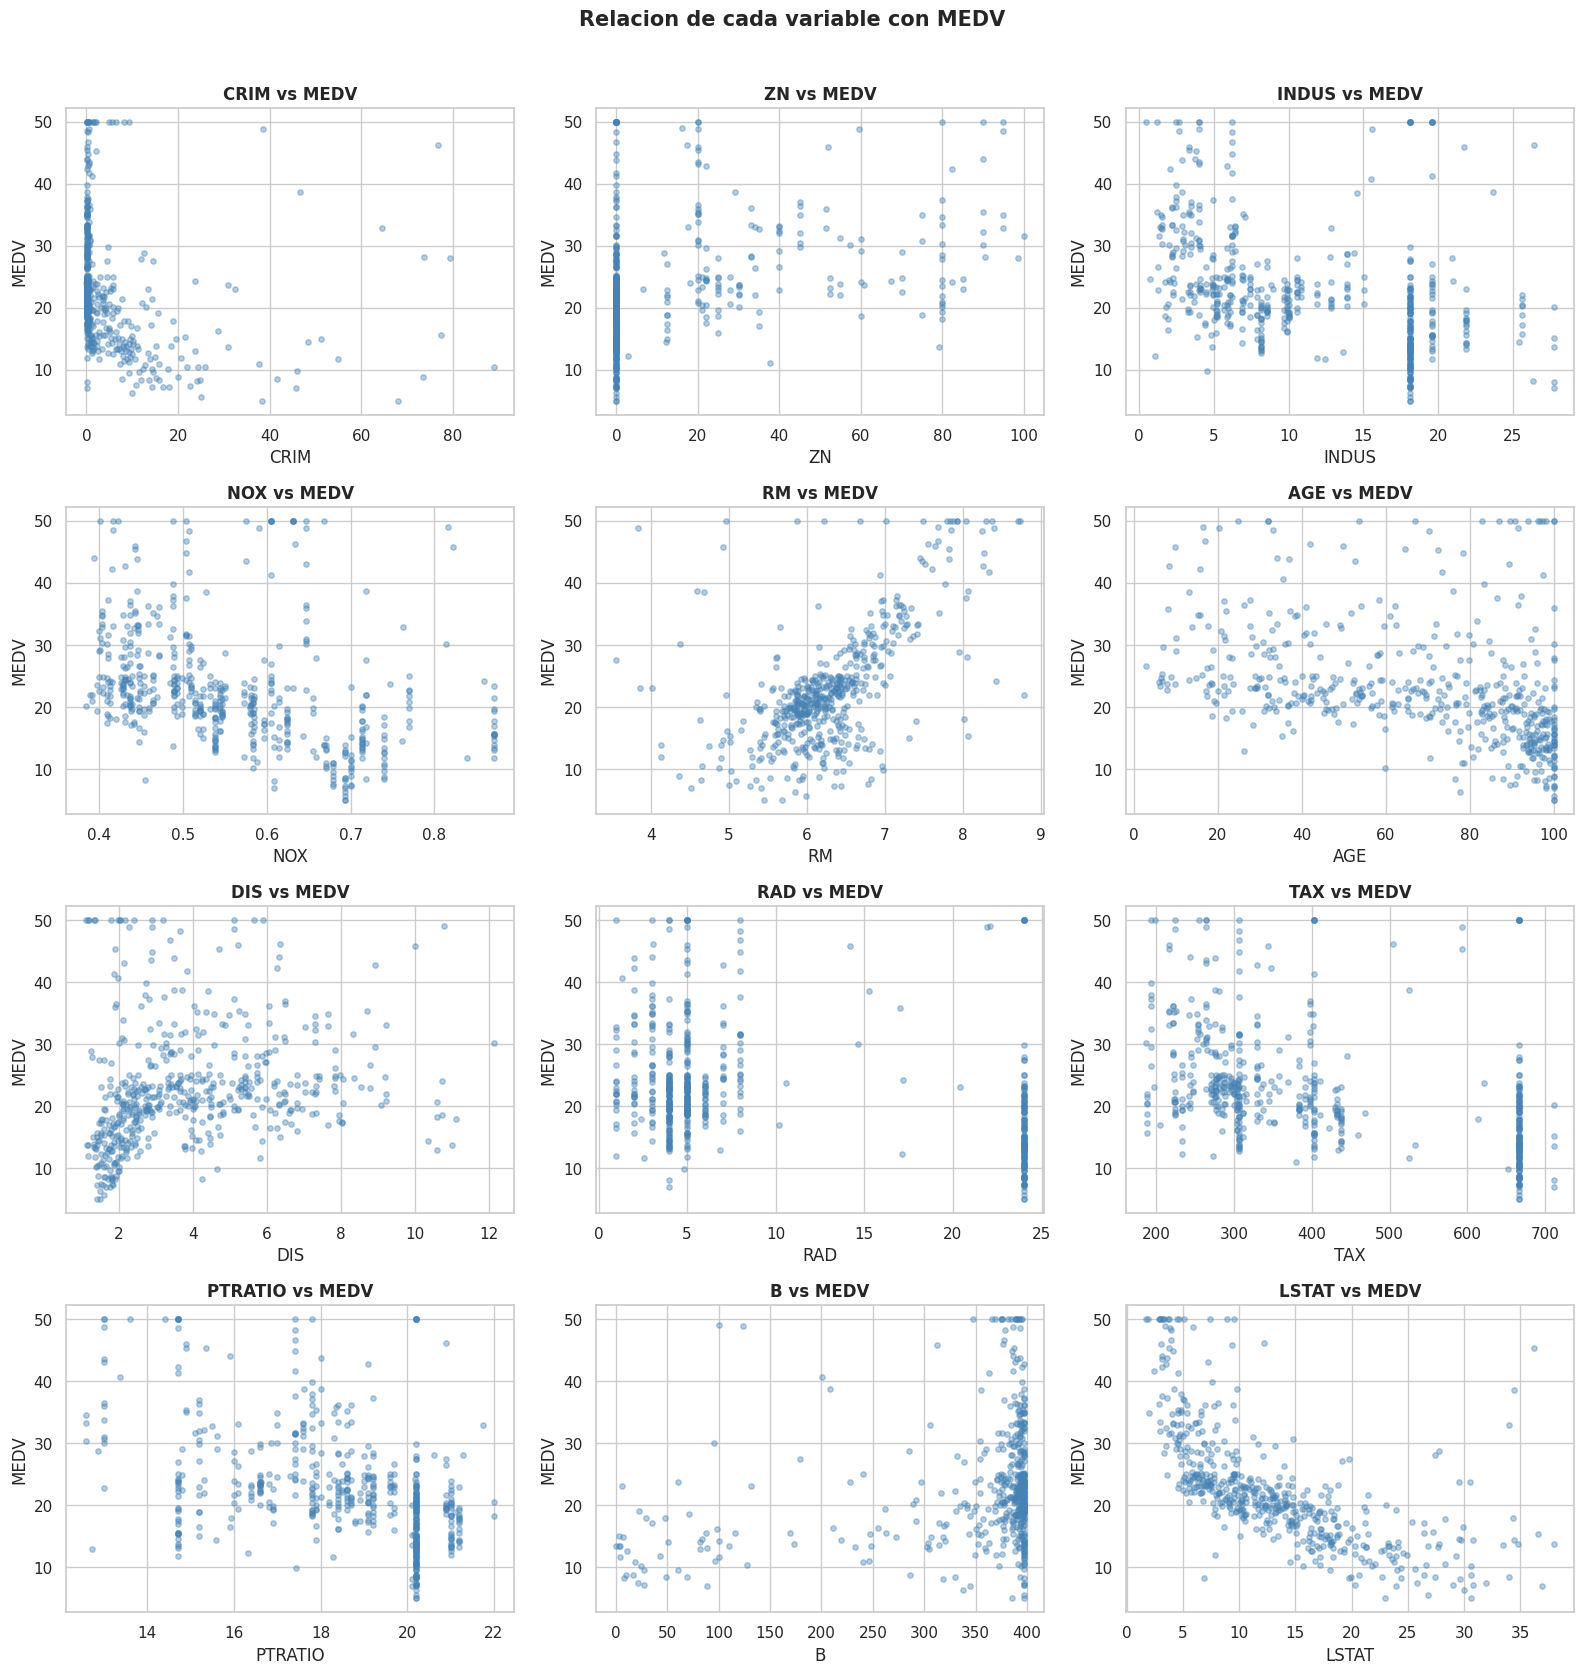

In [15]:
fig, axes = plt.subplots(n_rows, n_cols, figsize=(16, 4 * n_rows))
axes = axes.flatten()

for i, col in enumerate(cols_numericas_continuas):
    ax = axes[i]
    ax.scatter(df[col], df[variable_target], alpha=0.4, s=15, color='steelblue')
    ax.set_xlabel(col)
    ax.set_ylabel(variable_target)
    ax.set_title(f'{col} vs {variable_target}', fontweight='bold')

for j in range(len(cols_numericas_continuas), len(axes)):
    axes[j].set_visible(False)

plt.suptitle(f'Relacion de cada variable con {variable_target}', fontsize=15, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

**Lectura rápida:** `LSTAT` muestra una relación negativa clara (y algo curva) con `MEDV`, y `RM` una relación positiva bastante lineal. Variables como `CHAS` o `DIS` muestran relaciones más débiles o difusas a simple vista. Esto se confirma cuantitativamente en la matriz de correlación (3.8).

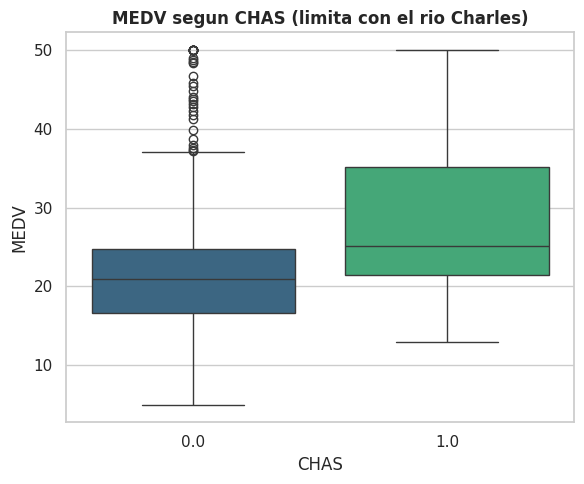

In [16]:
# CHAS es binaria: mejor visualizarla con un boxplot de MEDV segun la categoria, no un scatter
fig, ax = plt.subplots(figsize=(6, 5))
sns.boxplot(data=df, x='CHAS', y=variable_target, ax=ax, palette='viridis')
ax.set_title(f'{variable_target} segun CHAS (limita con el rio Charles)', fontweight='bold')
plt.tight_layout()
plt.show()

## 3.7 Codificación de variables categóricas

En este dataset **no es necesario aplicar técnicas de encoding** (one-hot encoding, label encoding, etc.) porque no hay variables categóricas de tipo texto:

- **CHAS** ya está codificada como variable *dummy* (0/1), que es exactamente el formato que necesitaría un one-hot encoding para una variable binaria. No requiere transformación adicional.
- **RAD**, si bien conceptualmente es un índice/categoría ordinal, se mantiene como variable numérica: en el dataset de Boston tradicionalmente se trata así (y no como one-hot) porque tiene una relación de orden con la accesibilidad a autopistas, y convertirla en dummies agregaría muchas columnas dispersas para un dataset de solo ~500 filas. Dejamos esta decisión documentada como una simplificación razonable, aclarando que podría explorarse como alternativa en la optimización de hiperparámetros.

En síntesis: el dataset ya llega "listo" en términos de codificación, algo poco frecuente pero cierto para este caso particular.

## 3.8 Matriz de correlación

Calculamos la correlación de Pearson (relaciones lineales) entre todas las variables numéricas, incluyendo el target. Esto sirve para dos cosas:

1. **Selección/priorización de variables**: identificar qué predictores están más asociados linealmente con `MEDV`.
2. **Detección de colinealidad**: identificar pares de predictores muy correlacionados entre sí, lo cual puede afectar la estabilidad de los coeficientes en regresión lineal (y que se puede tratar más adelante con regularización Ridge/Lasso).

*Nota: esta matriz se calcula sobre el dataset completo (antes del split) únicamente con fines exploratorios/descriptivos; no se usa para ajustar ningún modelo ni para seleccionar variables de forma definitiva, por lo que no genera fuga de datos hacia el conjunto de test.*

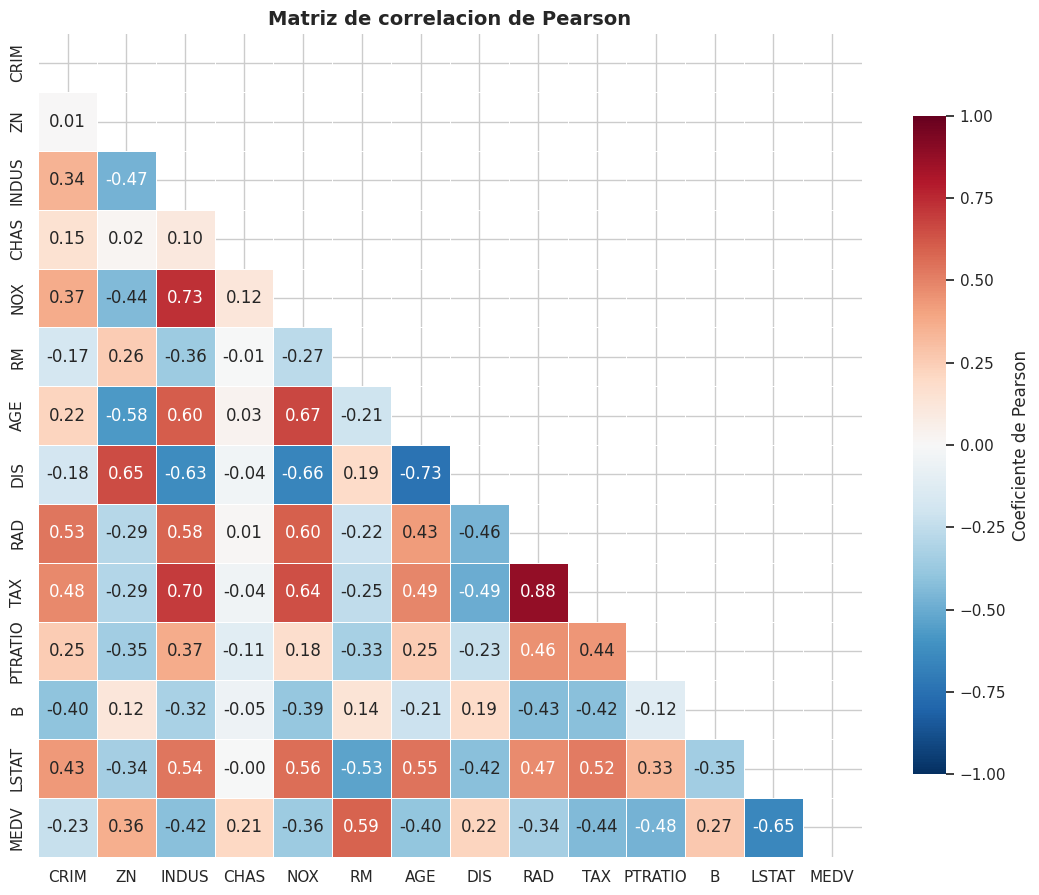

In [17]:
corr_pearson = df.corr(method='pearson')

mask = np.triu(np.ones_like(corr_pearson, dtype=bool))
fig, ax = plt.subplots(figsize=(11, 9))
sns.heatmap(corr_pearson, mask=mask, annot=True, fmt='.2f', cmap='RdBu_r', center=0,
            vmin=-1, vmax=1, square=True, linewidths=0.5, ax=ax,
            cbar_kws={'shrink': 0.8, 'label': 'Coeficiente de Pearson'})
ax.set_title('Matriz de correlacion de Pearson', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

In [18]:
# Correlacion de cada variable con el target, ordenada por magnitud
corr_target = corr_pearson[variable_target].drop(variable_target).sort_values(key=abs, ascending=False)
print(f'Correlacion de cada variable con {variable_target} (ordenada por magnitud):')
print('=' * 55)
print(corr_target.round(3))

Correlacion de cada variable con MEDV (ordenada por magnitud):
LSTAT     -0.653
RM         0.588
PTRATIO   -0.475
TAX       -0.438
INDUS     -0.419
AGE       -0.397
ZN         0.362
NOX       -0.361
RAD       -0.342
B          0.270
CRIM      -0.228
DIS        0.223
CHAS       0.206
Name: MEDV, dtype: float64


In [19]:
# Deteccion de pares de predictores con posible colinealidad (|r| >= 0.8)
UMBRAL_COLINEALIDAD = 0.8
predictores = [c for c in df.columns if c != variable_target]
corr_pred = df[predictores].corr(method='pearson')

print(f'Pares de predictores con |r| >= {UMBRAL_COLINEALIDAD} (posible colinealidad):')
print('=' * 60)
for i in range(len(corr_pred.columns)):
    for j in range(i + 1, len(corr_pred.columns)):
        r = corr_pred.iloc[i, j]
        if abs(r) >= UMBRAL_COLINEALIDAD:
            print(f'  {corr_pred.columns[i]} <-> {corr_pred.columns[j]}: r = {r:.3f}')

Pares de predictores con |r| >= 0.8 (posible colinealidad):
  RAD <-> TAX: r = 0.883


**Lectura de resultados:**

- Los predictores más correlacionados (en valor absoluto) con `MEDV` suelen ser **LSTAT** (negativa, fuerte) y **RM** (positiva, fuerte), coherente con lo observado en los scatterplots.
- Se detecta colinealidad relevante entre **TAX** y **RAD** (ambas relacionadas con la infraestructura/impuestos del barrio) y entre **NOX** e **INDUS**/**AGE**/**DIS** (variables todas asociadas a la industrialización de la zona). Esto no impide entrenar una regresión lineal, pero sí sugiere que los coeficientes individuales de esas variables pueden ser inestables o difíciles de interpretar por separado. Es un buen argumento para probar **Ridge** (que maneja bien la colinealidad) más adelante, en el punto 4.
- Este análisis es preliminar: al trabajar solo con el dataset completo por motivos exploratorios, se recalculará /confirmará la relación de cada variable con el target usando exclusivamente el conjunto de entrenamiento cuando se seleccionen variables para el modelo.

## 3.9 Detección de outliers (método IQR)

Usamos el método del rango intercuartílico (Tukey, 1977): un valor se considera outlier si cae fuera de $[Q_1 - 1.5 \cdot IQR,\; Q_3 + 1.5 \cdot IQR]$.

In [20]:
IQR_FACTOR = 1.5
reporte_outliers = []

for col in cols_numericas_continuas + [variable_target]:
    datos = df[col].dropna()
    q1, q3 = datos.quantile(0.25), datos.quantile(0.75)
    iqr = q3 - q1
    lim_inf, lim_sup = q1 - IQR_FACTOR * iqr, q3 + IQR_FACTOR * iqr
    n_out = ((datos < lim_inf) | (datos > lim_sup)).sum()
    reporte_outliers.append({
        'Variable': col, 'Lim_inf': round(lim_inf, 2), 'Lim_sup': round(lim_sup, 2),
        'N_outliers': n_out, 'Pct_outliers': round(n_out / len(datos) * 100, 1)
    })

df_outliers = pd.DataFrame(reporte_outliers).sort_values('Pct_outliers', ascending=False)
df_outliers

,Variable,Lim_inf,Lim_sup,N_outliers,Pct_outliers
10,B,334.97,432.68,87,16.5
0,CRIM,-6.61,11.24,64,12.2
1,ZN,-30.00,50.00,55,10.5
4,RM,4.74,7.76,41,7.8
12,MEDV,2.43,40.62,37,6.9
11,LSTAT,-7.92,32.21,11,2.1
6,DIS,-2.66,10.06,10,1.9
3,NOX,0.19,0.90,0,0.0
2,INDUS,-14.33,37.56,0,0.0
8,TAX,-301.50,1246.50,0,0.0


**Decisión sobre outliers:** variables como `CRIM`, `B`, `ZN`, `CHAS` y el propio `MEDV` muestran un porcentaje considerable de "outliers" según IQR, pero en varios casos esto es esperable dado que son variables con distribución naturalmente asimétrica (por ejemplo, `CHAS` es binaria: sus "outliers" son simplemente la clase minoritaria, no errores). Además, `MEDV` es conocido en el dataset de Boston por estar *censurado* en 50 (valor tope), lo cual genera una acumulación de observaciones en ese extremo que el método IQR marca como atípicas sin que sean errores de carga.

Dado que el dataset tiene solo ~530 filas, **no eliminamos ni recortamos (capping) los outliers en esta etapa**: quitar filas reduciría aún más el tamaño muestral y podría eliminar información legítima (barrios genuinamente distintos). La decisión es **conservarlos** y, en el punto 4/5, evaluar si modelos regularizados (Ridge/Lasso) mitigan su impacto en los coeficientes; si el error de test resulta muy sensible a estos puntos, se documentará como limitación en las conclusiones.

## 3.10 División train-test: ¿por qué en este momento?

Hacemos la división en conjunto de entrenamiento y de prueba **ahora**, es decir, *antes* de imputar los valores faltantes restantes y de estandarizar las variables. La razón es evitar **fuga de datos (data leakage)**:

- La imputación por mediana/moda y la estandarización (`StandardScaler`) **calculan estadísticos a partir de los datos** (mediana, media, desvío estándar).
- Si esos estadísticos se calculan sobre el dataset completo (train + test) y luego se aplican a ambos, el conjunto de entrenamiento "ve" información (aunque sea agregada) del conjunto de prueba. Esto hace que la evaluación final sea optimista y no refleje el desempeño real del modelo ante datos nuevos.
- La buena práctica es: **dividir primero**, y luego **ajustar (`fit`) cualquier transformador solo con el conjunto de entrenamiento**, aplicándolo (`transform`) después a ambos conjuntos.

Todo lo hecho hasta acá (histogramas, boxplots, matriz de correlación, conteo de outliers) es puramente **descriptivo/exploratorio**: no ajusta ningún parámetro que después se use para transformar los datos, por lo que hacerlo sobre el dataset completo no genera fuga de información hacia el modelo.

Usamos una partición 80/20, razonable para un dataset de este tamaño (~530 filas), y fijamos `random_state` para que la partición sea reproducible.

In [21]:
X = df[predictores].copy()
y = df[variable_target].copy()

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE
)

print(f'Train: {X_train.shape[0]} filas ({X_train.shape[0]/len(X)*100:.1f}%)')
print(f'Test:  {X_test.shape[0]} filas ({X_test.shape[0]/len(X)*100:.1f}%)')

Train: 428 filas (80.0%)
Test:  107 filas (20.0%)


## 3.11 Imputación de faltantes y estandarización (ajustadas solo con train)

### Imputación

Como se decidió en 3.4, imputamos:
- Variables numéricas continuas: con la **mediana** de cada columna (robusta a sesgo/outliers).
- `CHAS` (binaria): con la **moda** (valor más frecuente), ya que la mediana/media no tienen sentido interpretativo directo para una variable binaria.

En ambos casos, el imputador se **ajusta únicamente con `X_train`**.

In [22]:
imputer_continuas = SimpleImputer(strategy='median')
imputer_binaria = SimpleImputer(strategy='most_frequent')

# Ajuste (fit) solo con train
X_train[cols_numericas_continuas] = imputer_continuas.fit_transform(X_train[cols_numericas_continuas])
X_train[variable_binaria] = imputer_binaria.fit_transform(X_train[variable_binaria])

# Aplicacion (transform) a test con los estadisticos aprendidos en train
X_test[cols_numericas_continuas] = imputer_continuas.transform(X_test[cols_numericas_continuas])
X_test[variable_binaria] = imputer_binaria.transform(X_test[variable_binaria])

print('Nulos restantes en X_train:', X_train.isnull().sum().sum())
print('Nulos restantes en X_test:', X_test.isnull().sum().sum())

Nulos restantes en X_train: 0
Nulos restantes en X_test: 0


### Estandarización

Escalamos las variables numéricas con `StandardScaler` ($z = \frac{x-\mu}{\sigma}$), necesario porque:

- Las variables tienen escalas muy distintas (por ejemplo, `TAX` llega a cientos mientras `NOX` está entre 0 y 1). Esto afecta especialmente a modelos que dependen de distancias o de la magnitud de los coeficientes, como **regresión con descenso por gradiente** y **regularización (Ridge/Lasso/Elastic Net)**, ya que penalizan los coeficientes sin tener en cuenta la escala original de cada variable.
- Igual que con la imputación, el `scaler` se ajusta **solo con train** y se aplica después a test, para no filtrar información.

No estandarizamos `CHAS` porque ya es binaria (0/1) y estandarizarla no aporta valor interpretativo (es una práctica común dejar las dummies sin escalar).

In [23]:
scaler = StandardScaler()
cols_a_escalar = cols_numericas_continuas  # no incluye CHAS

X_train_scaled = X_train.copy()
X_test_scaled = X_test.copy()

X_train_scaled[cols_a_escalar] = scaler.fit_transform(X_train[cols_a_escalar])
X_test_scaled[cols_a_escalar] = scaler.transform(X_test[cols_a_escalar])

print('Verificacion (train, deberia dar media ~0 y std ~1):')
print(X_train_scaled[cols_a_escalar].agg(['mean', 'std']).T.round(3))

Verificacion (train, deberia dar media ~0 y std ~1):
         mean    std
CRIM     -0.0  1.001
ZN        0.0  1.001
INDUS     0.0  1.001
NOX      -0.0  1.001
RM        0.0  1.001
AGE      -0.0  1.001
DIS       0.0  1.001
RAD       0.0  1.001
TAX      -0.0  1.001
PTRATIO   0.0  1.001
B        -0.0  1.001
LSTAT    -0.0  1.001


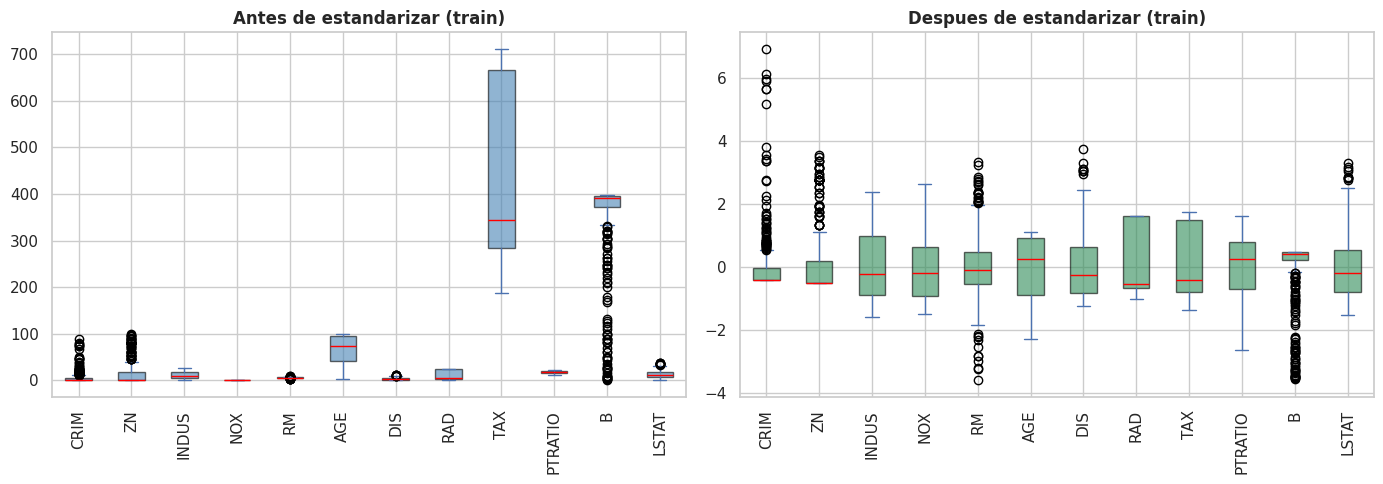

In [24]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

X_train[cols_a_escalar].plot.box(ax=axes[0], patch_artist=True,
    boxprops=dict(facecolor='steelblue', alpha=0.6), medianprops=dict(color='red'))
axes[0].set_title('Antes de estandarizar (train)', fontweight='bold')
axes[0].tick_params(axis='x', rotation=90)

X_train_scaled[cols_a_escalar].plot.box(ax=axes[1], patch_artist=True,
    boxprops=dict(facecolor='seagreen', alpha=0.6), medianprops=dict(color='red'))
axes[1].set_title('Despues de estandarizar (train)', fontweight='bold')
axes[1].tick_params(axis='x', rotation=90)

plt.tight_layout()
plt.show()

## 3.12 Conclusiones del análisis descriptivo

- El dataset original tenía 556 filas y 14 columnas, todas numéricas. Tras eliminar los registros sin valor de `MEDV` (target), quedaron 535 filas utilizables.
- Todas las variables presentaban entre 2.7% y 5% de valores faltantes, sin patrones evidentes entre columnas, compatible con un mecanismo **MCAR**. Se decidió imputar (mediana para continuas, moda para `CHAS`) en lugar de eliminar filas, dado el bajo porcentaje de nulos y el tamaño ya acotado del dataset.
- No se encontraron registros duplicados.
- Varias variables (`CRIM`, `ZN`, `B`) muestran sesgo alto; `RM` y `MEDV` son las más cercanas a la simetría.
- `LSTAT` y `RM` son los predictores más correlacionados con `MEDV` (negativo y positivo respectivamente); se detectó colinealidad entre `TAX`-`RAD` y entre `NOX` y varias variables de industrialización, lo cual será relevante al comparar regresión lineal simple contra modelos regularizados (Ridge) en los puntos 4 y 5.
- No fue necesario codificar variables categóricas: `CHAS` ya es una dummy y `RAD`, si bien es ordinal, se mantiene numérica por convención del dataset.
- Se detectaron outliers en varias variables mediante IQR, pero se decidió no eliminarlos por el tamaño reducido del dataset y porque varios responden a la naturaleza propia de la variable (ej. `CHAS` binaria, `MEDV` censurado en 50).
- La división train/test (80/20) se realizó **antes** de imputar y escalar, y esos dos pasos se ajustaron únicamente sobre `X_train`, evitando fuga de datos hacia el conjunto de test.
- **Nota ética:** la variable `B` (derivada de la proporción de población afroamericana por barrio) es un elemento controvertido del dataset de Boston Housing, señalado en la literatura reciente por codificar sesgos raciales históricos. Se mantiene en este trabajo por ser parte del enunciado del TP, pero vale la pena mencionarlo en la conclusión general y, si el equipo lo considera, discutir su exclusión como ejercicio de reflexión sobre fairness en modelos predictivos.

Con los datos ya explorados, limpios, divididos en train/test e imputados/escalados sin fuga de información, el dataset queda listo para avanzar al **punto 4: implementación de los modelos de regresión**.